This notebook is an example how the base model can be augmented with the modular neural ODE. 

In [1]:
import jax.numpy as jnp
import jaxley as jx
import jax

%load_ext autoreload
%autoreload 2


In [2]:
from voltage_fitting.build_simulator import (
    get_experimental_data
)

# setup = "488683425"
# setup = "485574832"
# setup = "480353286"
setup = "473601979"

t_max = 80.0
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus
dt = 0.025

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.17000000178813934


In [3]:
from voltage_fitting.single_build_simulator import (
    setup_Na_K_simulator_step,
    build_Na_K_cell,
    set_setup,
    get_Na_K_bounds,
    get_gating_bounds,
    get_power_bounds,
)
all_setup = set_setup(setup)


In [4]:
cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)#, Na_gating_params=jnp.zeros(40), K_gating_params=jnp.zeros(20), Ca_gating_params = jnp.zeros(20), use_CaT=True, use_CaL=False, use_Km=True)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

In [6]:
from voltage_fitting.neural_ode import simulate_with_nn, init_correction_network

master_key = jax.random.PRNGKey(0)
models, inv_transform_params, inv_transform_gatings, inv_transform_powers = init_correction_network(master_key, get_Na_K_bounds, get_power_bounds, get_gating_bounds, n_particles = 500)
predictions, added_currents = jax.vmap(simulate_with_nn, in_axes=(0, None, None, None, None, None, None, None, None, None, None))(models, setup_Na_K_simulator_step, cell, cut, t_max, all_setup, i_amp, v_data, inv_transform_params, inv_transform_gatings, inv_transform_powers)

Number of parameters: 11


Text(0.5, 1.0, 'Added current from neural ODE')

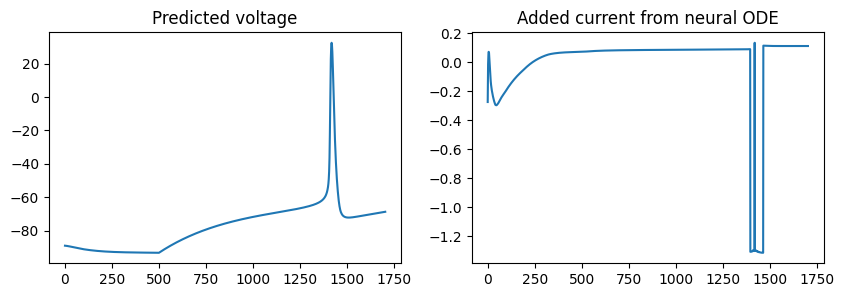

In [7]:
import matplotlib.pyplot as plt

idx = 1

fig, axs = plt.subplots(1,2, figsize = (10, 3))
axs[0].plot(predictions[idx])
axs[0].set_title("Predicted voltage")
axs[1].plot(added_currents[idx])
axs[1].set_title("Added current from neural ODE")